# Option Pricing Comparison with Tenokonda Sobol' Sequence

In this notebook we will present some examples which showcase the accuracy of the option prices computed using the Sobol' sequences generated from Tenokonda's direction number dataset.

## Pricing a European option with Monte Carlo and quasi-Monte Carlo

We work on a filtered probability space
$$(\Omega,\mathcal{F},(\mathcal{F}_t)_{0\le t\le T},\mathbb{Q}),$$
where $\mathbb{Q}$ is the **risk-neutral pricing measure** and $(W_t^{\mathbb{Q}})_{t\ge 0}$ is a Brownian motion. Under the real-world measure one would typically write the stock drift as $\mu$, but for pricing we move to $\mathbb{Q}$, under which discounted asset prices are martingales.

Assuming a constant risk-free rate $r$ and volatility $\sigma$, the stock price follows the Black-Scholes SDE
$$
dS_t = r S_t\,dt + \sigma S_t\,dW_t^{\mathbb{Q}}, \qquad S_0>0.
$$

The terminal value is
$$
S_T = S_0 \exp\left(\left(r-\tfrac12\sigma^2\right)T + \sigma\sqrt{T}\,Z\right),
\qquad Z\sim N(0,1).
$$

A European option depends only on the terminal stock price $S_T$. For strike $K$, the payoffs are
$$
\text{Call payoff} = (S_T-K)^+, \qquad
\text{Put payoff} = (K-S_T)^+,
$$
where $x^+ = \max(x,0)$.

Under the risk-neutral measure, the option value is the discounted expected payoff:
$$
C_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\!\left[(S_T-K)^+\right], \qquad
P_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\!\left[(K-S_T)^+\right].
$$

If interest rates are stochastic, the constant discount factor $e^{-rT}$ is replaced by a stochastic discount factor inside the expectation.

### Closed-form benchmark

In the Black-Scholes model these prices are known analytically:
$$
C_0 = S_0 N(d_1) - K e^{-rT} N(d_2),
$$
$$
P_0 = K e^{-rT} N(-d_2) - S_0 N(-d_1),
$$
with
$$
d_1 = \frac{\ln(S_0/K) + (r+\tfrac12\sigma^2)T}{\sigma\sqrt{T}},
\qquad
d_2 = d_1 - \sigma\sqrt{T}.
$$

These formulas are useful as a reference when comparing simulation-based prices.

### Monte Carlo approximation

Monte Carlo approximates the expectation by simulating many independent samples of the terminal stock price. If $U^{(n)}\sim U(0,1)$, we set
$$
Z^{(n)} = \Phi^{-1}(U^{(n)}),
$$
and then compute
$$
S_T^{(n)} = S_0 \exp\left(\left(r-\tfrac12\sigma^2\right)T + \sigma\sqrt{T}\,Z^{(n)}\right).
$$

The Monte Carlo estimators are
$$
\hat C_N^{\mathrm{MC}} = e^{-rT}\frac{1}{N}\sum_{n=1}^N (S_T^{(n)}-K)^+,
$$
$$
\hat P_N^{\mathrm{MC}} = e^{-rT}\frac{1}{N}\sum_{n=1}^N (K-S_T^{(n)})^+.
$$

For a plain European option in Black-Scholes, one normal draw is enough because the payoff depends only on $S_T$. More generally, if we discretize the SDE on a time grid
$$
0=t_0<t_1<\cdots<t_m=T,
$$
we generate a vector of normal shocks and evolve the path step by step via
$$
S_{t_{i+1}} = S_{t_i}\exp\left(\left(r-\tfrac12\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}\,Z_i\right).
$$

Classical Monte Carlo converges at the familiar rate $O(N^{-1/2})$.

### Quasi-Monte Carlo approximation

Quasi-Monte Carlo (QMC) uses the same pricing idea, but replaces pseudo-random uniforms by deterministic **low-discrepancy points**, for example Sobol' points:
$$
u^{(1)},u^{(2)},\dots,u^{(N)} \in [0,1)^d.
$$

These points fill the unit cube more evenly than standard pseudo-random samples. After transforming them componentwise,
$$
z_i^{(n)} = \Phi^{-1}(u_i^{(n)}),
$$
we build the corresponding terminal values or paths and average the discounted payoffs exactly as before:
$$
\hat C_N^{\mathrm{QMC}} = e^{-rT}\frac{1}{N}\sum_{n=1}^N (S_T(u^{(n)})-K)^+.
$$

So the pricing formula is unchanged; only the sampling rule is different.

The main advantage is that QMC often produces a smaller integration error than standard Monte Carlo for the same number of paths. When the problem is written in multiple dimensions, the quality of the Sobol' construction across dimensions is important, which is why improved direction numbers can lead to more accurate prices.

In [1]:
from pricing_helper import *
from plotting_helper import plot_with_error_panel
from tklds.interface.generators import get_sequence_enum

In [2]:
num_paths = 2**12
spot = 100.0
strike = 100.0
rate = 0.0
volatility = 0.2
expiry = 1.0
cp = 1

tk_dimension_grid_a = np.arange(2, 50001)
jk_dimension_grid_b = np.arange(2, 21021)

sequence_enum = get_sequence_enum()

tk_sequence = sequence_enum.TKRG_A_AP5
jk_sequence = sequence_enum.NEW_JOE_KUO

tk_normals  = sobol_normal_matrix(num_paths=num_paths, num_dimensions=int(tk_dimension_grid_a.max()), sequence=tk_sequence)
jk_normals  = sobol_normal_matrix(num_paths=num_paths, num_dimensions=int(jk_dimension_grid_b.max()), sequence=jk_sequence)

In [3]:
bs_reference_price, tk_prices, jk_prices = run_sobol_price_comparison(
    spot=spot, strike=strike, rate=rate, volatility=volatility,
    expiry=expiry, z_a=tk_normals, z_b=jk_normals, dimension_grid_a=tk_dimension_grid_a,
    dimension_grid_b=jk_dimension_grid_b, cp=cp,)
bs_reference_delta, tk_delta, jk_delta = run_sobol_delta_comparison(spot=spot, strike=strike, rate=rate, volatility=volatility,
    expiry=expiry, z_a=tk_normals, z_b=jk_normals, dimension_grid_a=tk_dimension_grid_a,
    dimension_grid_b=jk_dimension_grid_b, cp=cp,)
bs_reference_vega, tk_vega, jk_vega = run_sobol_vega_comparison(spot=spot, strike=strike, rate=rate, volatility=volatility,
    expiry=expiry, z_a=tk_normals, z_b=jk_normals, dimension_grid_a=tk_dimension_grid_a,
    dimension_grid_b=jk_dimension_grid_b, cp=cp,)

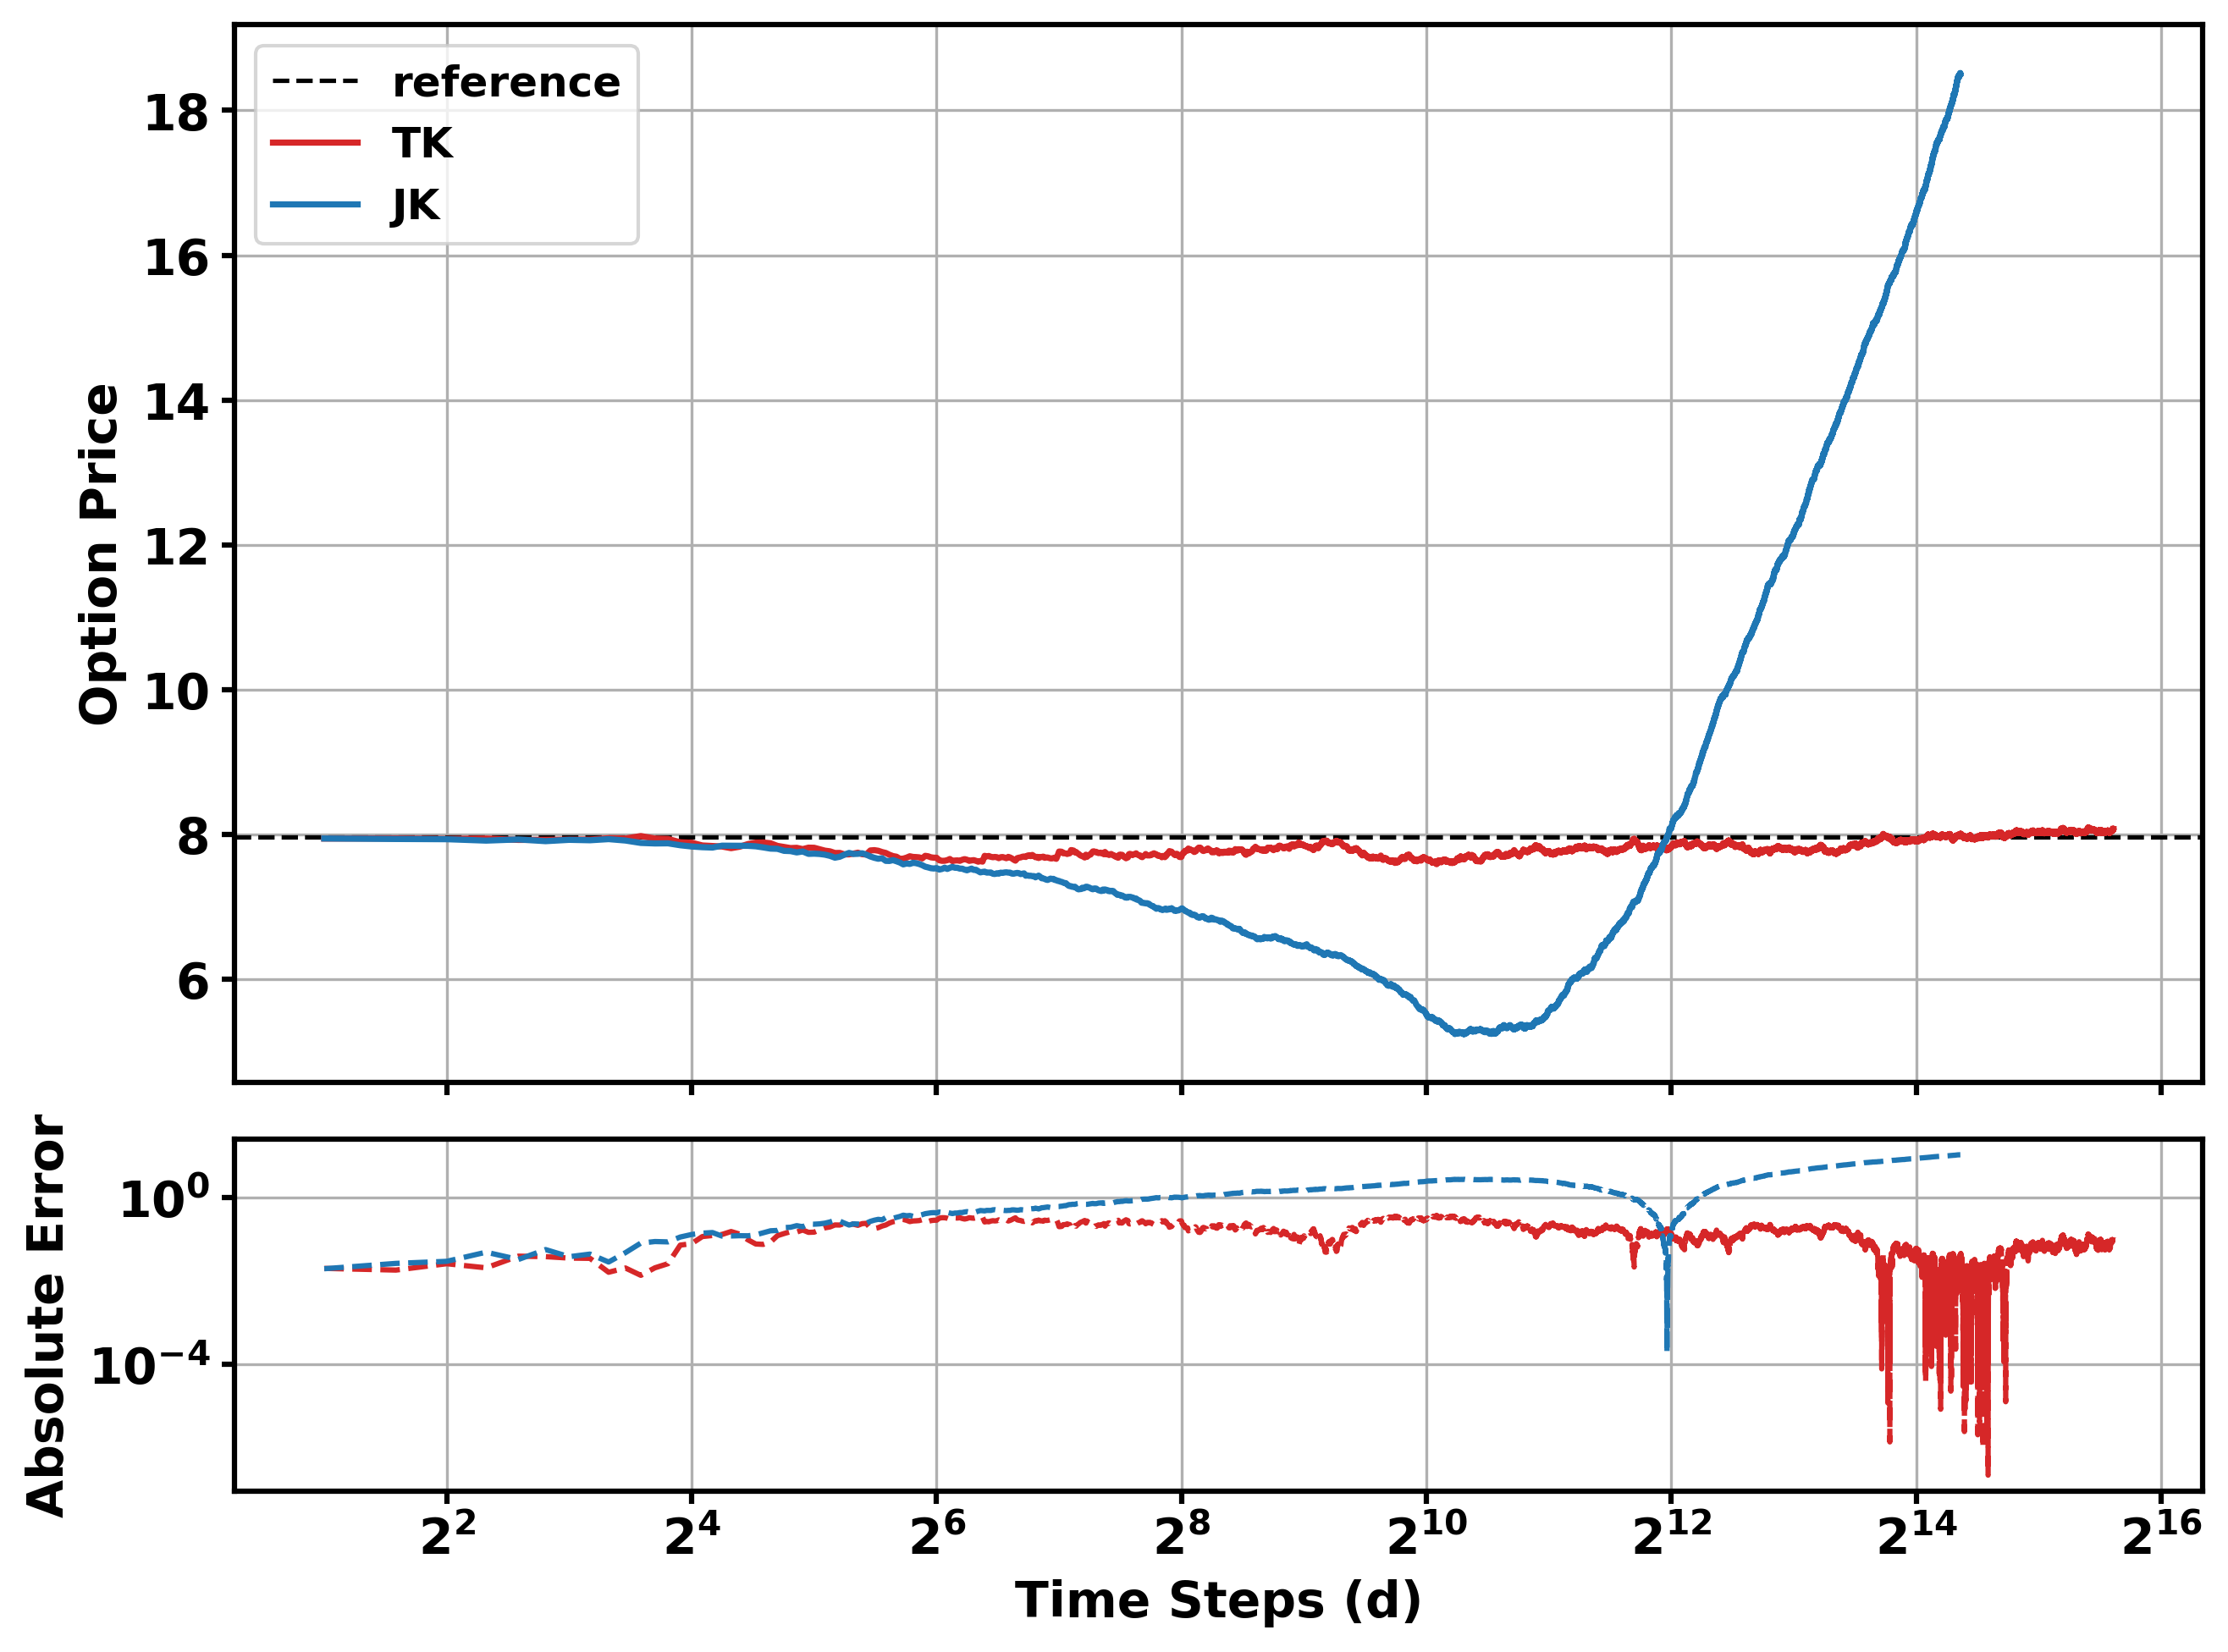

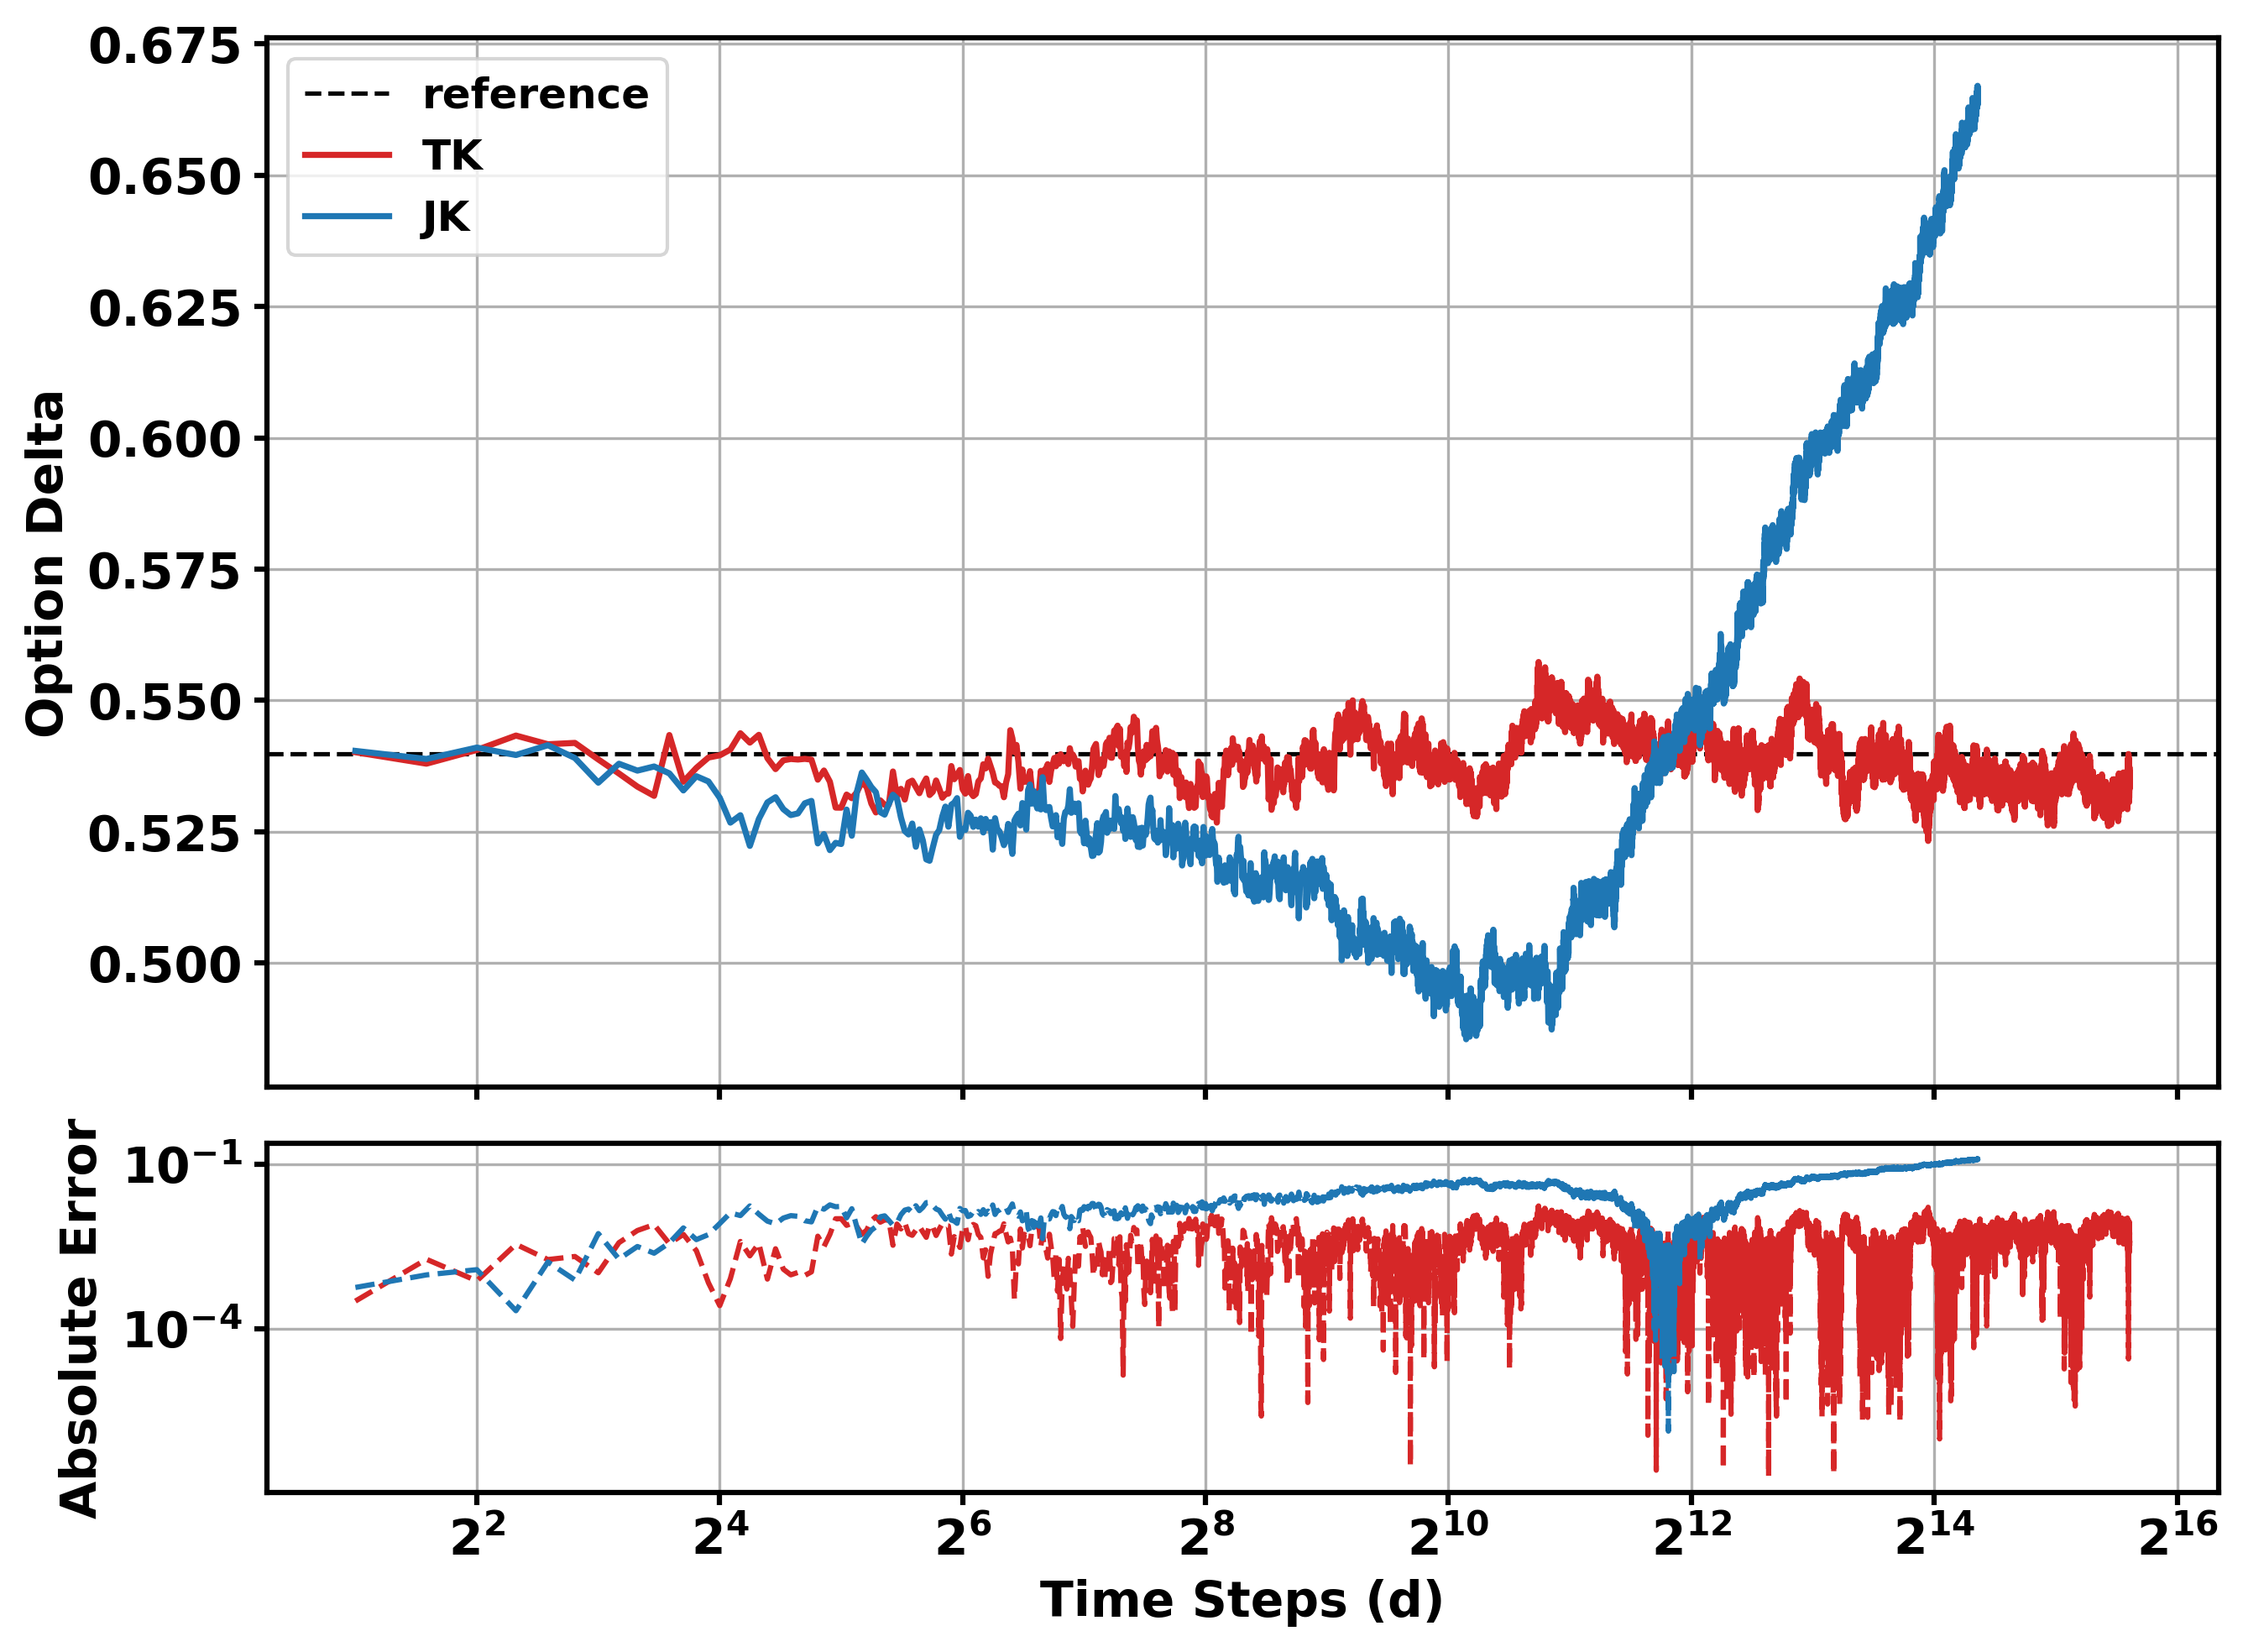

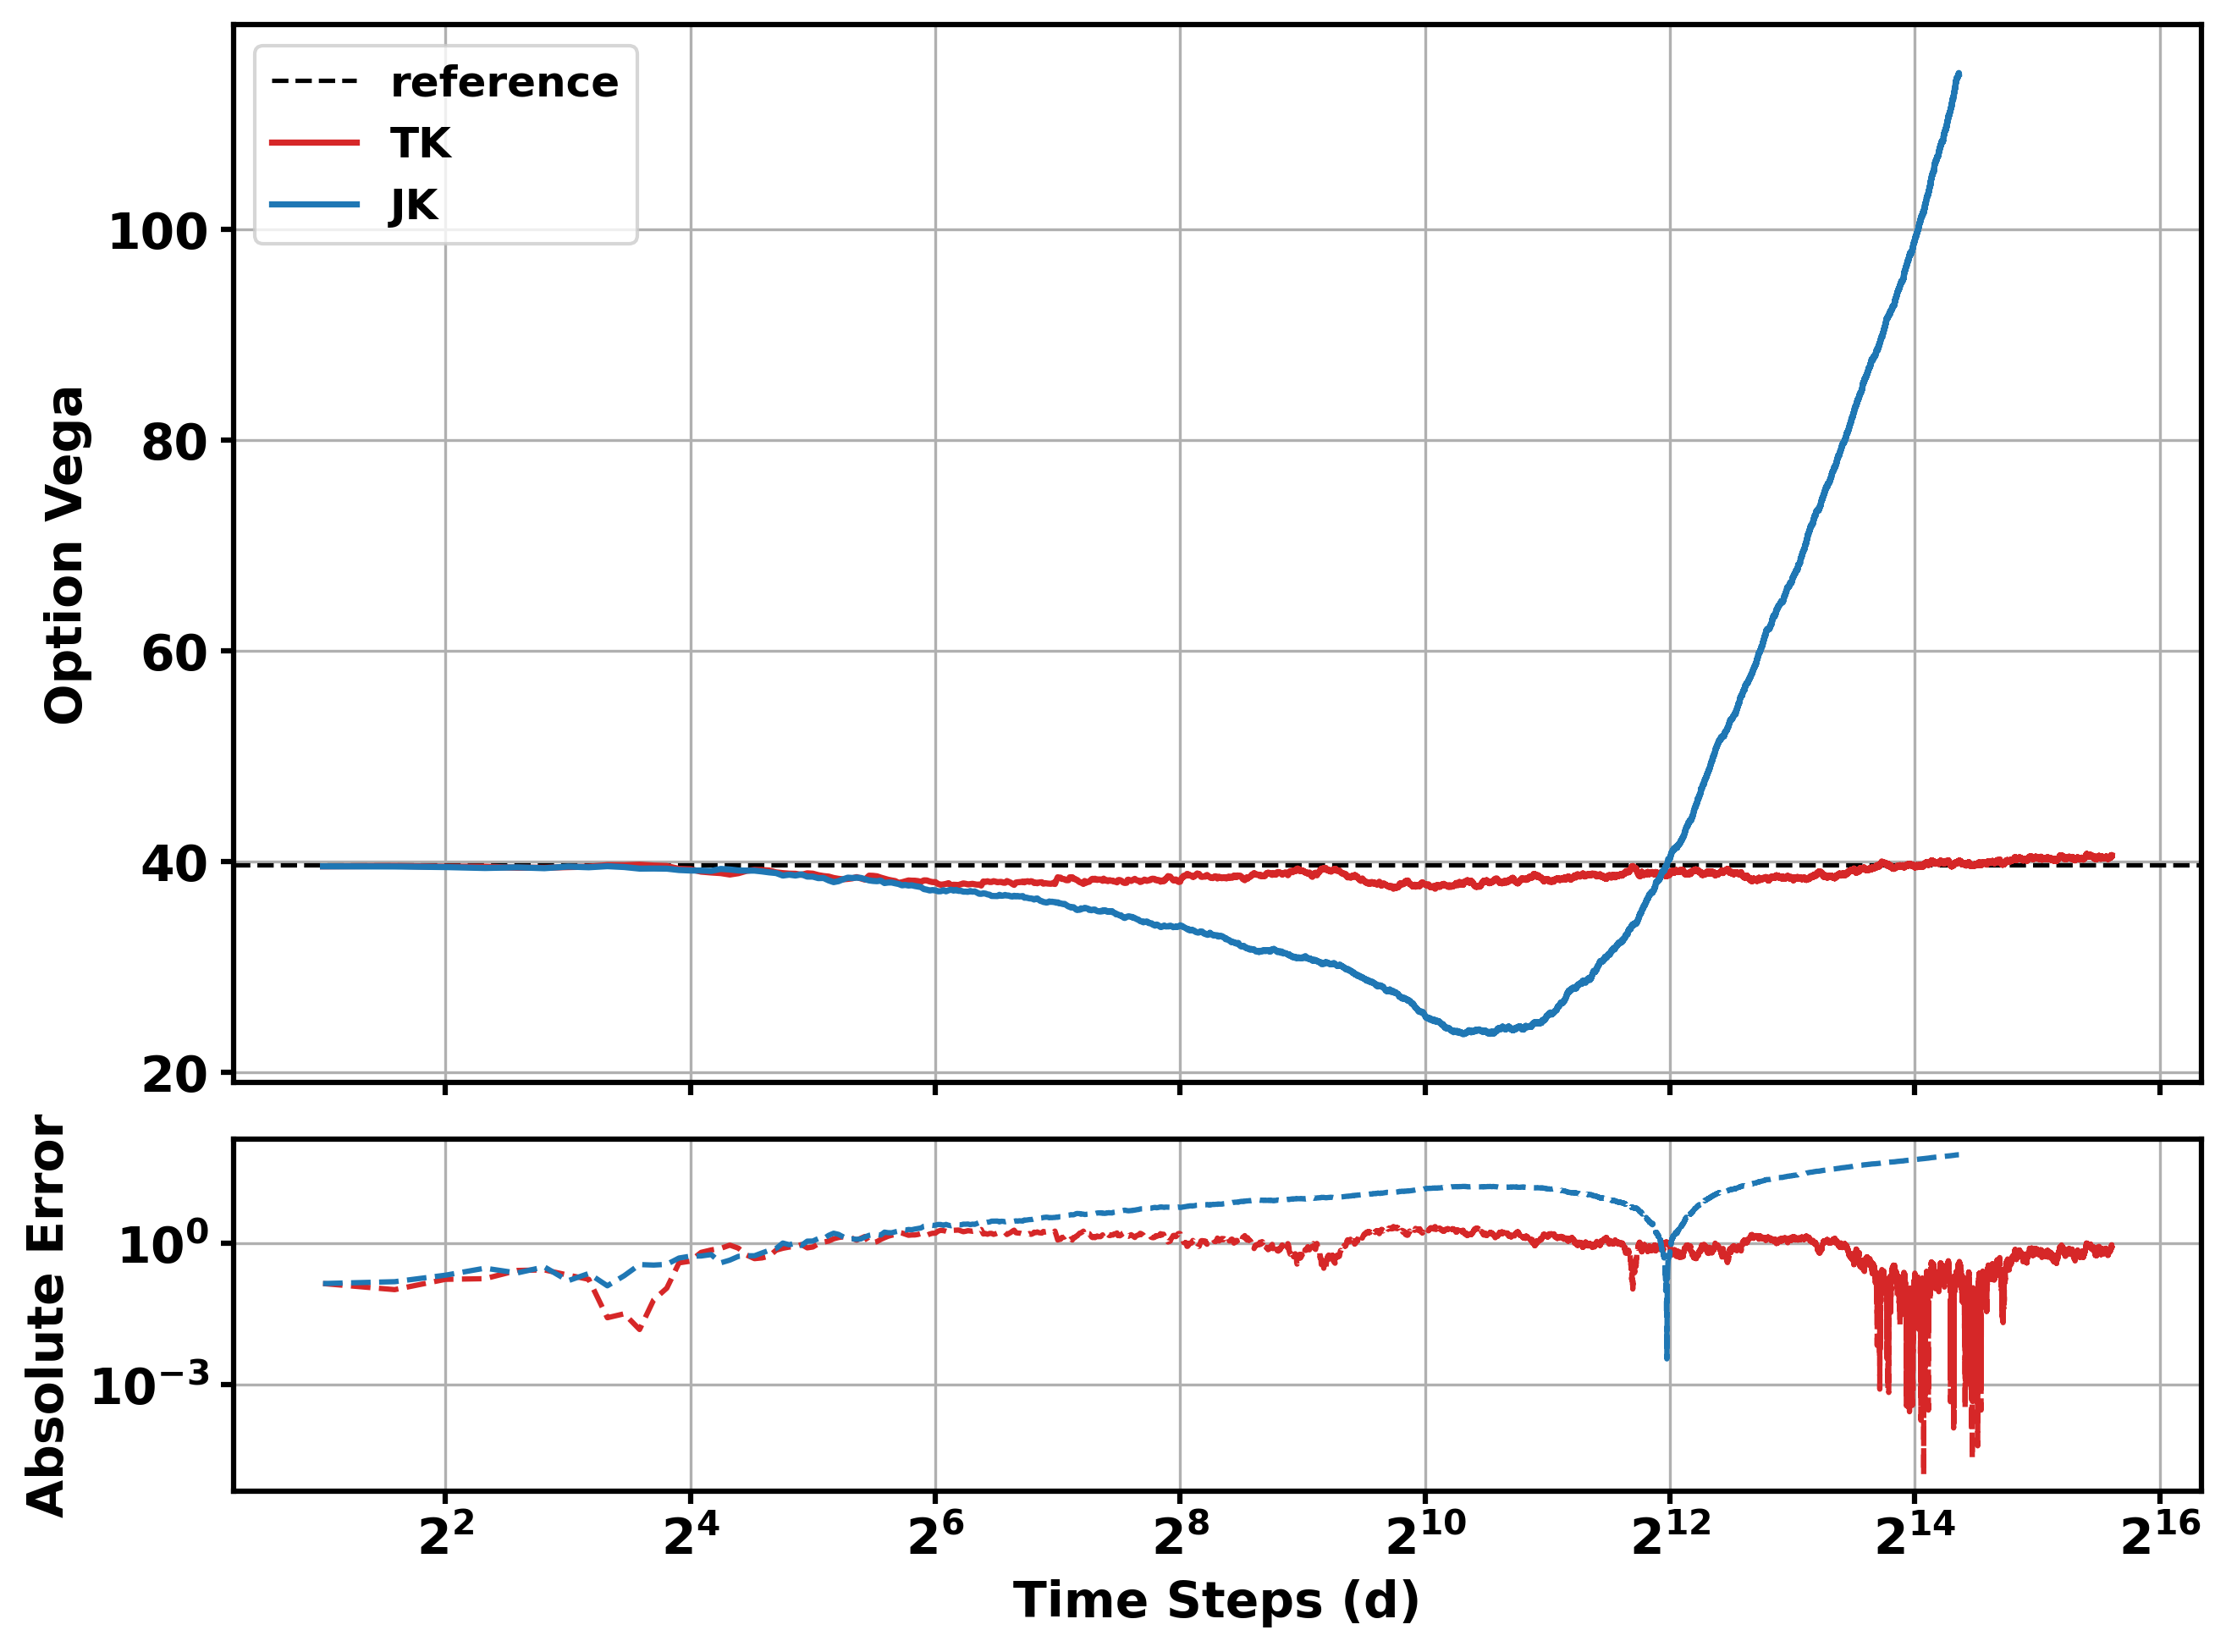

(<Figure size 3000x2250 with 2 Axes>,
 (<Axes: ylabel='Option Vega'>,
  <Axes: xlabel='Time Steps (d)', ylabel='Absolute Error'>))

In [5]:
plot_with_error_panel(x_data = [tk_dimension_grid_a, jk_dimension_grid_b], y_data = [tk_prices, jk_prices],
                      y_axis_label_top='Option Price',
                      y_axis_label_bottom='Absolute Error',
                      x_axis_label='Time Steps (d)',
                      y_data_label=['TK', 'JK'],
                      y_data_colors=['tab:red', 'tab:blue'],
                      reference_x_data=tk_dimension_grid_a,
                      reference_y_data=bs_reference_price,)
plot_with_error_panel(x_data = [tk_dimension_grid_a, jk_dimension_grid_b], y_data = [tk_delta, jk_delta],
                      y_axis_label_top='Option Delta',
                      y_axis_label_bottom='Absolute Error',
                      x_axis_label='Time Steps (d)',
                      y_data_label=['TK', 'JK'],
                      y_data_colors=['tab:red', 'tab:blue'],
                      reference_x_data=tk_dimension_grid_a,
                      reference_y_data=bs_reference_delta,)
plot_with_error_panel(x_data = [tk_dimension_grid_a, jk_dimension_grid_b], y_data = [tk_vega, jk_vega],
                      y_axis_label_top='Option Vega',
                      y_axis_label_bottom='Absolute Error',
                      x_axis_label='Time Steps (d)',
                      y_data_label=['TK', 'JK'],
                      y_data_colors=['tab:red', 'tab:blue'],
                      reference_x_data=tk_dimension_grid_a,
                      reference_y_data=bs_reference_vega,)